# D2 — Invoice / PO / GRN Matching Model

At 1M invoices/month, manual AP reconciliation doesn't scale.
This model flags mismatches between invoices, POs and GRNs
before payment is triggered.

Two layers: rules for explainability, ML for edge cases.
Dataset: 300 invoices, 25% mismatch rate, 6 mismatch types.


In [1]:
# Install check — verify all packages are available
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", __import__('sklearn').__version__)
print("✅ All packages ready")

pandas: 2.2.2
numpy: 1.26.4
sklearn: 1.5.0
✅ All packages ready


Step 1 - Load invoice data

In [4]:
# Load the invoice dataset
import os

# Set correct path relative to notebook location
data_path = os.path.join(os.getcwd(), '..', 'data', 'invoices.csv')
print("Looking for file at:", data_path)

df_invoices = pd.read_csv(data_path)

print("Shape:", df_invoices.shape)
print("Invoices:", df_invoices['invoice_id'].nunique())
print("Vendors:", df_invoices['vendor_id'].nunique())
print("\nFirst 5 rows:")
df_invoices.head()

Looking for file at: /Users/AkNew/Desktop/smartpay-ap/notebooks/../data/invoices.csv
Shape: (1500, 11)
Invoices: 300
Vendors: 20

First 5 rows:


,invoice_id,invoice_date,vendor_id,vendor_name,currency,line_item_number,item_code,description,quantity,unit_price,line_total
0,INV0001,23-11-2024,V004,Vendor_4,USD,1,ITM0048,Component gadget widget device assembly,19,213.85,4063.15
1,INV0001,23-11-2024,V004,Vendor_4,USD,2,ITM0002,Gadget assembly widget,7,359.43,2516.01
2,INV0001,23-11-2024,V004,Vendor_4,USD,3,ITM0045,Module assembly component part device gadget m...,9,81.96,737.64
3,INV0001,23-11-2024,V004,Vendor_4,USD,4,ITM0049,Widget module module module component,2,366.22,732.44
4,INV0001,23-11-2024,V004,Vendor_4,USD,5,ITM0035,Accessory module assembly,20,443.30,8866.00


## Step 2 — Generate Synthetic PO and GRN Data

Real AP systems have Purchase Orders and Goods Receipt Notes in SAP/Oracle.
Since we only have invoice data, I'm generating matching POs and GRNs
synthetically, then injecting 6 types of realistic mismatches.

In [5]:

import random
import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Generate Purchase Orders from invoices
def generate_purchase_orders(invoices):
    rows = []
    po_counter = 1
    for invoice_id, group in invoices.groupby("invoice_id", sort=False):
        po_id = f"PO{po_counter:04d}"
        po_counter += 1
        invoice_date = pd.to_datetime(group["invoice_date"], dayfirst=True).iloc[0]
        po_date = invoice_date - pd.Timedelta(days=random.randint(30, 90))
        for _, line in group.iterrows():
            rows.append({
                "po_id": po_id,
                "invoice_id": invoice_id,
                "line_item_number": line["line_item_number"],
                "item_code": line["item_code"],
                "po_quantity": line["quantity"],
                "po_unit_price": line["unit_price"],
                "po_line_total": line["line_total"],
                "currency": line["currency"],
            })
    return pd.DataFrame(rows)

df_po = generate_purchase_orders(df_invoices)
print("POs generated:", df_po["po_id"].nunique())
print("PO lines:", len(df_po))
df_po.head(3)


POs generated: 300
PO lines: 1500


,po_id,invoice_id,line_item_number,item_code,po_quantity,po_unit_price,po_line_total,currency
0,PO0001,INV0001,1,ITM0048,19,213.85,4063.15,USD
1,PO0001,INV0001,2,ITM0002,7,359.43,2516.01,USD
2,PO0001,INV0001,3,ITM0045,9,81.96,737.64,USD


In [6]:

# Generate Goods Receipt Notes
def generate_grn(po):
    rows = []
    grn_counter = 1
    for po_id, group in po.groupby("po_id", sort=False):
        grn_id = f"GRN{grn_counter:04d}"
        grn_counter += 1
        for _, line in group.iterrows():
            rows.append({
                "grn_id": grn_id,
                "po_id": po_id,
                "invoice_id": line["invoice_id"],
                "item_code": line["item_code"],
                "line_item_number": line["line_item_number"],
                "grn_quantity": line["po_quantity"],
            })
    return pd.DataFrame(rows)

df_grn = generate_grn(df_po)
print("GRNs generated:", df_grn["grn_id"].nunique())
print("GRN lines:", len(df_grn))
df_grn.head(3)


GRNs generated: 300
GRN lines: 1500


,grn_id,po_id,invoice_id,item_code,line_item_number,grn_quantity
0,GRN0001,PO0001,INV0001,ITM0048,1,19
1,GRN0001,PO0001,INV0001,ITM0002,2,7
2,GRN0001,PO0001,INV0001,ITM0045,3,9


# 3 - Inject Mismatches

In [7]:
# Inject realistic mismatches into ~25% of rows
MISMATCH_RATE = 0.25
CURRENCIES = ["USD", "EUR", "INR", "GBP"]

def inject_mismatches(invoices, po, grn):
    merged = invoices.merge(
        po[["invoice_id", "line_item_number", "po_id",
            "po_quantity", "po_unit_price", "po_line_total"]],
        on=["invoice_id", "line_item_number"], how="left"
    ).merge(
        grn[["invoice_id", "line_item_number", "grn_id", "grn_quantity"]],
        on=["invoice_id", "line_item_number"], how="left"
    )

    merged["mismatch_type"] = "MATCH"
    merged["is_mismatch"] = 0

    mismatch_types = [
        "quantity_mismatch", "price_mismatch",
        "item_not_in_po", "duplicate_invoice",
        "grn_not_received", "currency_mismatch"
    ]

    n = int(len(merged) * MISMATCH_RATE)
    indices = random.sample(list(merged.index), n)
    types = (mismatch_types * (n // len(mismatch_types) + 1))[:n]
    random.shuffle(types)

    for idx, mtype in zip(indices, types):
        if mtype == "quantity_mismatch":
            orig = merged.at[idx, "quantity"]
            delta = random.choice([-1,1]) * random.randint(1, max(2, int(orig*0.2)))
            merged.at[idx, "quantity"] = max(1, orig + delta)
        elif mtype == "price_mismatch":
            orig = merged.at[idx, "unit_price"]
            merged.at[idx, "unit_price"] = round(orig * random.uniform(1.05, 1.20), 2)
        elif mtype == "grn_not_received":
            merged.at[idx, "grn_quantity"] = 0
        elif mtype == "duplicate_invoice":
            merged.at[idx, "invoice_id"] = merged.at[idx, "invoice_id"] + "_DUP"
        elif mtype == "currency_mismatch":
            curr = merged.at[idx, "currency"]
            merged.at[idx, "currency"] = random.choice([c for c in CURRENCIES if c != curr])

        merged.at[idx, "mismatch_type"] = mtype
        merged.at[idx, "is_mismatch"] = 1

    return merged

df_labeled = inject_mismatches(df_invoices, df_po, df_grn)

print("Total rows:", len(df_labeled))
print("Clean matches:", (df_labeled["is_mismatch"]==0).sum())
print("Mismatches:", (df_labeled["is_mismatch"]==1).sum())
print()
print(df_labeled["mismatch_type"].value_counts())


Total rows: 1500
Clean matches: 1125
Mismatches: 375

mismatch_type
MATCH                1125
item_not_in_po         63
price_mismatch         63
quantity_mismatch      63
currency_mismatch      62
grn_not_received       62
duplicate_invoice      62
Name: count, dtype: int64


Step 3 - Save dataset to Disk

In [8]:
# Save the labeled dataset
output_path = "../data/labeled_dataset.csv"
df_labeled.to_csv(output_path, index=False)
print(f"Labeled dataset saved to {output_path}")
print(f"Shape: {df_labeled.shape}")
print(f"Columns: {list(df_labeled.columns)}")

Labeled dataset saved to ../data/labeled_dataset.csv
Shape: (1500, 19)
Columns: ['invoice_id', 'invoice_date', 'vendor_id', 'vendor_name', 'currency', 'line_item_number', 'item_code', 'description', 'quantity', 'unit_price', 'line_total', 'po_id', 'po_quantity', 'po_unit_price', 'po_line_total', 'grn_id', 'grn_quantity', 'mismatch_type', 'is_mismatch']


In [9]:
# Load labeled dataset from disk
df = pd.read_csv("../data/labeled_dataset.csv")

print("Loaded:", df.shape)
print("Mismatches:", df["is_mismatch"].sum())
print("Clean:", (df["is_mismatch"]==0).sum())

Loaded: (1500, 19)
Mismatches: 375
Clean: 1125


In [10]:
# Feature engineering
# We create numeric features the ML model can learn from

def engineer_features(df):
    out = df.copy()
    
    # How different is invoice qty from PO qty?
    out["qty_delta"] = out["quantity"] - out["po_quantity"]
    out["qty_delta_pct"] = abs(out["qty_delta"]) / (out["po_quantity"] + 1e-9)
    
    # How different is invoice price from PO price?
    out["price_delta_pct"] = abs(
        (out["unit_price"] - out["po_unit_price"]) / (out["po_unit_price"] + 1e-9)
    )
    
    # Invoice total vs PO total
    out["line_total_delta"] = out["line_total"] - out["po_line_total"]
    
    # GRN vs invoice quantity
    out["grn_vs_invoice_qty"] = out["grn_quantity"] - out["quantity"]
    
    return out

df = engineer_features(df)
print("Features added. New shape:", df.shape)


Features added. New shape: (1500, 24)


Step 4 - Train Random Forest Model

In [12]:
# Apply rule flags to loaded dataset
df["flag_qty_mismatch"] = (
    df["quantity"] != df["po_quantity"]
).astype(int)

df["flag_price_mismatch"] = (
    abs(df["unit_price"] - df["po_unit_price"]) / df["po_unit_price"] > 0.01
).astype(int)

df["flag_grn_not_received"] = (
    df["grn_quantity"] == 0
).astype(int)

df["flag_duplicate"] = df["invoice_id"].apply(
    lambda x: 1 if "_DUP" in str(x) else 0
)

print("Flag columns added")
print(df[["flag_qty_mismatch","flag_price_mismatch",
          "flag_grn_not_received","flag_duplicate"]].sum())


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Flag columns added
flag_qty_mismatch        62
flag_price_mismatch      63
flag_grn_not_received    62
flag_duplicate           62
dtype: int64


In [ ]:
# Define features for ML model
FEATURES = [
    "qty_delta",
    "qty_delta_pct", 
    "price_delta_pct",
    "line_total_delta",
    "grn_vs_invoice_qty",
    "grn_quantity",
    "quantity",
    "unit_price",
    "line_item_number",
    "flag_qty_mismatch",
    "flag_price_mismatch",
    "flag_grn_not_received",
    "flag_duplicate"
]

X = df[FEATURES].fillna(0)
y = df["is_mismatch"]

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Mismatch rate in test:", y_test.mean().round(2))


## Train the model

In [14]:
# Train Random Forest classifier
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model trained successfully")
print("Test predictions:", len(y_pred))

Model trained successfully
Test predictions: 300


## Evaluation of model

In [15]:
# Evaluate the model
print("=" * 50)
print("SMARTPAY AP — MODEL EVALUATION")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=["MATCH", "MISMATCH"]))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print("                Predicted MATCH  Predicted MISMATCH")
print(f"Actual MATCH         {cm[0][0]}              {cm[0][1]}")
print(f"Actual MISMATCH      {cm[1][0]}              {cm[1][1]}")


SMARTPAY AP — MODEL EVALUATION

Classification Report:
              precision    recall  f1-score   support

       MATCH       0.88      1.00      0.93       225
    MISMATCH       1.00      0.57      0.73        75

    accuracy                           0.89       300
   macro avg       0.94      0.79      0.83       300
weighted avg       0.91      0.89      0.88       300


Confusion Matrix:
                Predicted MATCH  Predicted MISMATCH
Actual MATCH         225              0
Actual MISMATCH      32              43


Top 10 Most Important Features:
              feature  importance
       flag_duplicate    0.197381
   grn_vs_invoice_qty    0.150699
      price_delta_pct    0.121087
  flag_price_mismatch    0.113250
         grn_quantity    0.105241
    flag_qty_mismatch    0.070139
        qty_delta_pct    0.066997
           unit_price    0.059237
flag_grn_not_received    0.037998
            qty_delta    0.028852


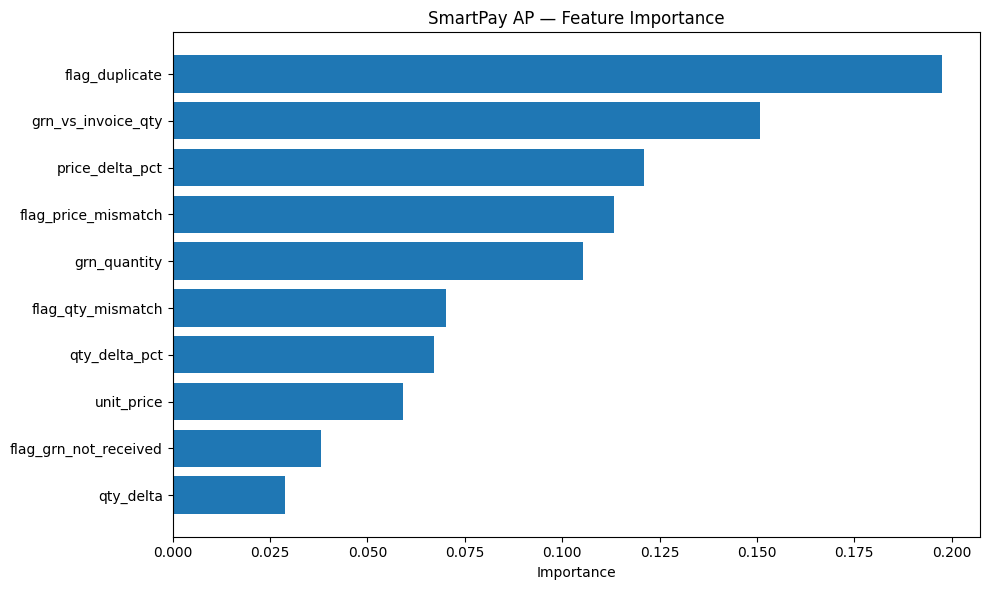

In [18]:
# Which features matter most to the model?
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["feature"].head(10),
    feature_importance["importance"].head(10)
)
plt.xlabel("Importance")
plt.title("SmartPay AP — Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
